## ROYALEX STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

royalex=pd.read_csv('../stock_data/royalex.csv') ## so it can be small letter. This is cool.
royalex=royalex.drop(columns=['high_price','low_price'])
royalex.rename(columns={'trade_date':'date'},inplace=True)
royalex['date']=pd.to_datetime(royalex['date'])
royalex['month']=royalex['date'].dt.month
royalex['quarter']=royalex['date'].dt.quarter
royalex['year']=royalex['date'].dt.year

royalex

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42827,ROYALEX,2017-01-03,0.50,0.50,16341,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43387,ROYALEX,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43497,ROYALEX,2017-01-05,0.50,0.50,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43607,ROYALEX,2017-01-06,0.50,0.50,2735,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43697,ROYALEX,2017-01-09,0.50,0.50,2558,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298124,ROYALEX,2026-07-13,1.45,1.45,669152,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298562,ROYALEX,2026-07-14,1.57,1.57,465037,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299000,ROYALEX,2026-07-15,1.57,1.57,758856,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299438,ROYALEX,2026-07-16,1.42,1.42,8784575,2026-07-16T15:10:03.113936+00:00,7,3,2026


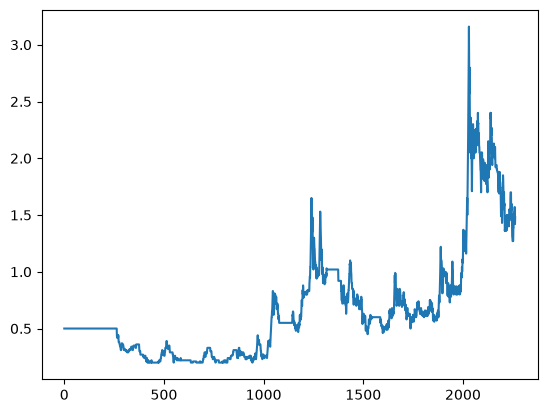

In [2]:
import matplotlib.pyplot as plt

plt.plot(royalex['close_price'])
plt.show()

In [3]:
royalex_end_month_df = (
    royalex
    .sort_values("date")
    .groupby(royalex["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

royalex_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45397,ROYALEX,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47219,ROYALEX,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49335,ROYALEX,2017-03-31,0.50,0.50,1000,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51162,ROYALEX,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53085,ROYALEX,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35361,ROYALEX,2026-03-31,1.64,1.64,4395887,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281187,ROYALEX,2026-04-30,1.36,1.36,18669386,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284253,ROYALEX,2026-05-29,1.41,1.41,1381733,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294181,ROYALEX,2026-06-30,1.27,1.27,964008,2026-06-30T15:10:03.08168+00:00,6,2,2026


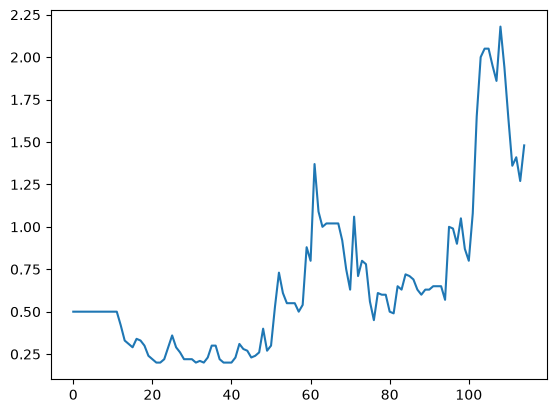

In [4]:
plt.plot(royalex_end_month_df['close_price'])
plt.show()

In [5]:
royalex_end_month_df['returns']=royalex_end_month_df['close_price'].pct_change()*100
royalex_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45397,ROYALEX,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47219,ROYALEX,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49335,ROYALEX,2017-03-31,0.50,0.50,1000,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51162,ROYALEX,2017-04-28,0.50,0.50,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53085,ROYALEX,2017-05-31,0.50,0.50,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35361,ROYALEX,2026-03-31,1.64,1.64,4395887,2026-03-31T15:00:02.085058+00:00,3,1,2026,-15.463918
111,281187,ROYALEX,2026-04-30,1.36,1.36,18669386,2026-04-30T15:00:02.170664+00:00,4,2,2026,-17.073171
112,284253,ROYALEX,2026-05-29,1.41,1.41,1381733,2026-05-29T15:00:02.455558+00:00,5,2,2026,3.676471
113,294181,ROYALEX,2026-06-30,1.27,1.27,964008,2026-06-30T15:10:03.08168+00:00,6,2,2026,-9.929078


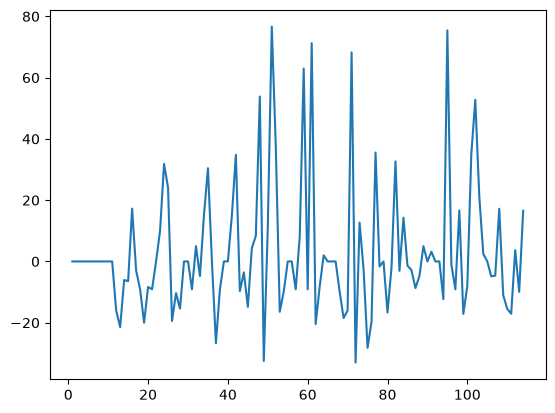

In [6]:
plt.plot(royalex_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(royalex_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.724900911136478), np.float64(3.08326375866038e-19), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(910.3890130388935))
stationary


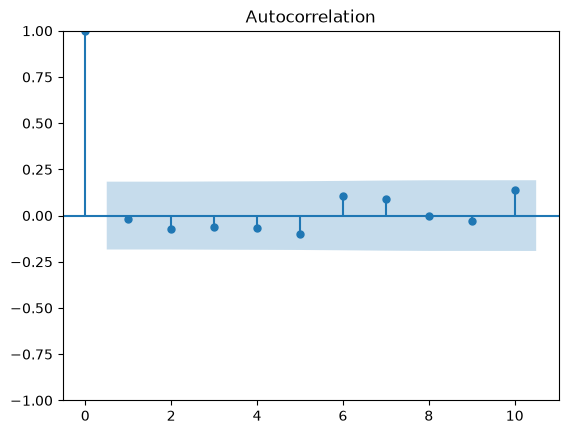

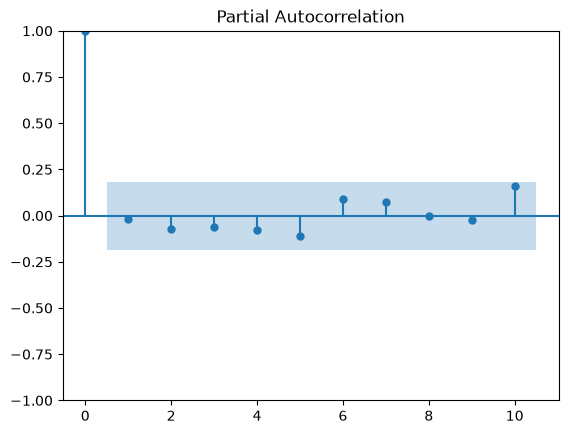

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(royalex_end_month_df['returns'].dropna(), lags=10)
plot_pacf(royalex_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=royalex_end_month_df['close_price'][:-10]
test=royalex_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -31.479533667652483]
[0, 0, 0, 0, 0, 1, -18.519352296343413]
[0, 0, 0, 0, 0, 2, -15.392540796663738]
[0, 0, 0, 0, 1, 0, -7.708370837083709]
[0, 0, 0, 0, 1, 1, -8.69216029147307]
[0, 0, 0, 0, 1, 2, -8.764257094618566]
[0, 0, 0, 0, 2, 0, -6.7637049418881166]
[0, 0, 0, 0, 2, 1, -7.101118954814693]
[0, 0, 0, 0, 2, 2, -6.867013650608282]
[0, 0, 0, 1, 0, 0, -9.22412074412285]
[0, 0, 0, 1, 0, 1, -10.026635285586266]
[0, 0, 0, 1, 0, 2, -10.030628037557408]
[0, 0, 0, 1, 1, 0, -8.055698345315097]
[0, 0, 0, 1, 1, 1, -8.588199912734305]
[0, 0, 0, 1, 1, 2, -9.48937805062412]
[0, 0, 0, 1, 2, 0, -7.019340531905609]
[0, 0, 0, 1, 2, 1, -7.080579226347872]
[0, 0, 0, 1, 2, 2, -8.080024136179427]
[0, 0, 0, 2, 0, 0, -9.555559282569531]
[0, 0, 0, 2, 0, 1, -9.975920850768677]
[0, 0, 0, 2, 0, 2, -12.137325386119185]
[0, 0, 0, 2, 1, 0, -7.709535550299526]
[0, 0, 0, 2, 1, 1, -9.824966791472683]
[0, 0, 0, 2, 1, 2, -9.982866745120425]
[0, 0, 0, 2, 2, 0, -7.695093261503596]
[0, 0, 0, 2, 2, 1, -5

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
663,2,2,0,1,2,0,-72.074048
664,2,2,0,1,2,1,-69.011083
655,2,2,0,0,2,1,-67.888527
656,2,2,0,0,2,2,-66.555206
665,2,2,0,1,2,2,-65.521069
...,...,...,...,...,...,...,...
534,2,0,1,2,1,0,-0.229290
291,1,0,1,2,1,0,-0.211094
318,1,0,2,2,1,0,-0.173319
267,1,0,0,2,2,0,-0.101744


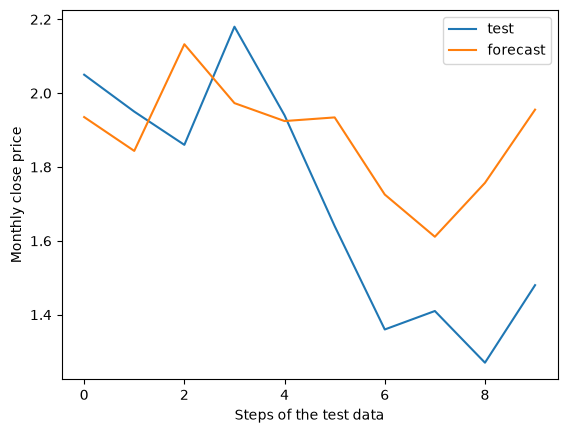

r2_score:  0.07247671980477177
rmse:  0.2942111190980713
description:  count    115.000000
mean       0.673826
std        0.476153
min        0.200000
25%        0.300000
50%        0.550000
75%        0.835000
max        2.180000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=royalex_end_month_df['close_price'][:-10]
y_test=royalex_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,0), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', royalex_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=royalex_end_month_df['returns'].dropna()[:-10]
test=royalex_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.04972297242452828]
[0, 0, 0, 0, 0, 1, -0.04268113619572578]
[0, 0, 0, 0, 0, 2, -0.0227312710777976]
[0, 0, 0, 0, 1, 0, -7.605947253293065]
[0, 0, 0, 0, 1, 1, -0.9661169251222794]
[0, 0, 0, 0, 1, 2, -0.8421472309288873]
[0, 0, 0, 0, 2, 0, -33.68683267356902]
[0, 0, 0, 0, 2, 1, -9.811551335081196]
[0, 0, 0, 0, 2, 2, -5.089501315842207]
[0, 0, 0, 1, 0, 0, -0.04238668473461704]
[0, 0, 0, 1, 0, 1, -0.22104129477075518]
[0, 0, 0, 1, 0, 2, -0.2817494047711331]
[0, 0, 0, 1, 1, 0, -2.0254252126054144]
[0, 0, 0, 1, 1, 1, -0.8502234771787462]
[0, 0, 0, 1, 1, 2, -1.591224298587921]
[0, 0, 0, 1, 2, 0, -8.255318078300732]
[0, 0, 0, 1, 2, 1, -4.206042220376825]
[0, 0, 0, 1, 2, 2, -5.209319043922571]
[0, 0, 0, 2, 0, 0, -0.02569352237222189]
[0, 0, 0, 2, 0, 1, -0.24639962673203186]
[0, 0, 0, 2, 0, 2, -0.5507221310425141]
[0, 0, 0, 2, 1, 0, -4.1734430874927435]
[0, 0, 0, 2, 1, 1, -1.8044567336222288]
[0, 0, 0, 2, 1, 2, -1.8410279052762912]
[0, 0, 0, 2, 2, 0, -9.798091773707828]
[0,

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-275.867544
168,0,2,0,0,2,0,-226.899695
654,2,2,0,0,2,0,-201.005410
406,1,2,0,0,0,1,-162.488284
414,1,2,0,1,0,0,-162.288175
...,...,...,...,...,...,...,...
515,2,0,1,0,0,2,-0.019303
299,1,0,2,0,0,2,-0.018333
288,1,0,1,2,0,0,-0.017625
272,1,0,1,0,0,2,-0.013764


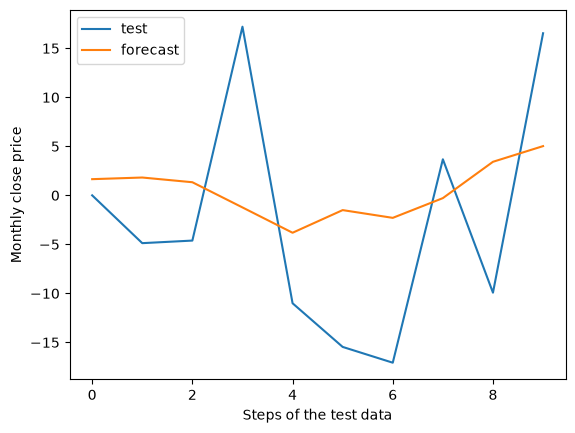

r2_score:  0.07526058421676529
rmse:  11.019597126364467
description:  count    114.000000
mean       2.852030
std       21.415834
min      -33.018868
25%       -9.090909
50%        0.000000
75%        5.000000
max       76.666667
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=royalex_end_month_df['returns'].dropna()[:-10]
y_test=royalex_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(0,0,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', royalex_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
